In [14]:
from pathlib import Path
from dataclasses import replace
import json
import os
import sys
import subprocess
import importlib

REQ_FILE = Path("requirements.txt")
if REQ_FILE.exists():
    try:
        import torch
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(REQ_FILE)])
if os.name == "nt":
    try:
        import torch_directml
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-directml"])

PIPELINE_VERSION = "schemeA-deliverable-fast-v2"
print(f"[main] pipeline_version={PIPELINE_VERSION}", flush=True)
PROJECT_ROOT = Path.cwd()
print(f"[main] cwd={PROJECT_ROOT}", flush=True)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import food_cv.training as training_module
import food_cv.data_pipeline as data_pipeline_module
import food_cv.evaluation as evaluation_module
importlib.reload(training_module)
importlib.reload(data_pipeline_module)
importlib.reload(evaluation_module)
from food_cv.classifier import build_resnet50_classifier, unfreeze_last_two_blocks
from food_cv.config import ProjectPaths
from food_cv.data_pipeline import DataConfig, Food101DataModule
from food_cv.evaluation import evaluate_classification_metrics, evaluate_nutrition_hit_rate, get_food101_test_images, run_scheme_a_batch_test
from food_cv.pipeline import MealPredictor
from food_cv.training import TrainConfig, train_classifier_two_stage

paths = ProjectPaths.from_root(PROJECT_ROOT)
demo_image = PROJECT_ROOT / "demo.jpg"

candidate_data_roots = [
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "datasets",
    PROJECT_ROOT / "food101_data",
    Path("/content/data"),
    Path("/content/datasets"),
    PROJECT_ROOT,
]
data_root = next((p for p in candidate_data_roots if p.exists()), PROJECT_ROOT)
data_config = DataConfig(data_root=data_root, batch_size=16, num_workers=0, image_size=160, download_if_missing=True, val_ratio=0.1, split_seed=42)
print(f"[main] split_policy=train/val from train split (val_ratio={data_config.val_ratio}), test from official test split")

print("[main] 初始化数据模块", flush=True)
try:
    datamodule = Food101DataModule(data_config)
    print("[main] 构建 DataLoader", flush=True)
    train_loader, val_loader, test_loader = datamodule.build_dataloaders()
    class_names = datamodule.get_class_names()
    print(f"train={len(train_loader.dataset)} val={len(val_loader.dataset)} test={len(test_loader.dataset)}")
    print(f"labels={len(class_names)}")
except Exception as e:
    train_loader = val_loader = test_loader = None
    class_names = []
    print(f"Data loader 初始化失败: {e}")

model = build_resnet50_classifier(num_classes=101, freeze_backbone=True)
stage1_checkpoint = paths.model_dir / "food101_resnet50_stage1.pt"
stage2_checkpoint = paths.model_dir / "food101_resnet50_stage2.pt"

TRAIN_PROFILE = "deliverable"  # deliverable(stronger) | smoke(fast)
if TRAIN_PROFILE == "deliverable":
    stage1_cfg = TrainConfig(epochs=3, lr=1e-4, device="directml" if os.name == "nt" else "auto", log_every_n_steps=10, max_steps_per_epoch=None, use_amp=True, require_accelerator=True, optimizer_foreach=False, min_effective_epochs=1.0, enforce_min_effective_epochs=True)
    stage2_cfg = TrainConfig(epochs=5, lr=3e-5, device="directml" if os.name == "nt" else "auto", log_every_n_steps=10, max_steps_per_epoch=None, use_amp=True, require_accelerator=True, optimizer_foreach=False, min_effective_epochs=1.0, enforce_min_effective_epochs=True)
else:
    stage1_cfg = TrainConfig(epochs=1, lr=1e-4, device="directml" if os.name == "nt" else "auto", log_every_n_steps=5, max_steps_per_epoch=200, use_amp=True, require_accelerator=True, optimizer_foreach=False, min_effective_epochs=0.05, enforce_min_effective_epochs=False)
    stage2_cfg = TrainConfig(epochs=1, lr=3e-5, device="directml" if os.name == "nt" else "auto", log_every_n_steps=5, max_steps_per_epoch=200, use_amp=True, require_accelerator=True, optimizer_foreach=False, min_effective_epochs=0.05, enforce_min_effective_epochs=False)

FORCE_FAST_CAP_STEPS = 0
if FORCE_FAST_CAP_STEPS > 0:
    stage1_steps = min(stage1_cfg.max_steps_per_epoch or FORCE_FAST_CAP_STEPS, FORCE_FAST_CAP_STEPS)
    stage2_steps = min(stage2_cfg.max_steps_per_epoch or FORCE_FAST_CAP_STEPS, FORCE_FAST_CAP_STEPS)
    stage1_cfg = replace(stage1_cfg, max_steps_per_epoch=stage1_steps, epochs=1)
    stage2_cfg = replace(stage2_cfg, max_steps_per_epoch=stage2_steps, epochs=1)
print(f"[main] effective_train_cfg: profile={TRAIN_PROFILE} stage1=(epochs={stage1_cfg.epochs},steps={stage1_cfg.max_steps_per_epoch}) stage2=(epochs={stage2_cfg.epochs},steps={stage2_cfg.max_steps_per_epoch})")

SKIP_TRAIN_IF_STAGE2_EXISTS = False
should_train = train_loader is not None and val_loader is not None
if SKIP_TRAIN_IF_STAGE2_EXISTS and stage2_checkpoint.exists():
    should_train = False
    print("[main] 检测到已有 stage2 checkpoint，已跳过训练（极速交付模式）")

if should_train:
    print("[main] 开始训练（两阶段：stage1->stage2）", flush=True)
    metrics = train_classifier_two_stage(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        stage1_save_path=stage1_checkpoint,
        stage1_config=stage1_cfg,
        stage2_save_path=stage2_checkpoint,
        stage2_config=stage2_cfg,
        unfreeze_fn=unfreeze_last_two_blocks,
    )
    print(json.dumps(metrics, ensure_ascii=False, indent=2))
    if not isinstance(metrics, dict) or "stage1" not in metrics or "stage2" not in metrics:
        raise RuntimeError("当前训练返回不是两阶段结构，疑似运行到旧代码路径。请重启内核后 Run All。")
    print(f"[main] stage1_checkpoint_exists={stage1_checkpoint.exists()}")
    print(f"[main] stage2_checkpoint_exists={stage2_checkpoint.exists()}")
    quick_eval = evaluate_classification_metrics(model=model, loader=test_loader, device=model.fc.weight.device, max_batches=80)
    print("[main] quick test metrics (sampled):")
    print(json.dumps(quick_eval, ensure_ascii=False, indent=2))
    with open(paths.model_dir / "class_names.json", "w", encoding="utf-8") as f:
        json.dump(class_names, f, ensure_ascii=False, indent=2)
    print("[main] 已保存 class_names 到 models/class_names.json")
else:
    print("[main] 跳过训练：使用现有 checkpoint 或当前数据不可用")

print("[main] 训练块执行结束。请运行下一个‘测试/预测块’进行推理与批量评估。")


[main] pipeline_version=schemeA-deliverable-fast-v2
[main] cwd=d:\CityU\Projects\CV_course_project
[main] split_policy=train/val from train split (val_ratio=0.1), test from official test split
[main] 初始化数据模块
[main] 构建 DataLoader
train=68175 val=7575 test=25250
labels=101
[main] effective_train_cfg: profile=deliverable stage1=(epochs=3,steps=None) stage2=(epochs=5,steps=None)
[main] 开始训练（两阶段：stage1->stage2）
[train] two-stage training: stage1(frozen) start
[train] backend=directml device=privateuseone:0
[train] epoch=1/3 start
[train] lr=0.0001000
[train] epoch_loop start total_steps=4261
[train] first_batch_loaded
[train] step=10/4261 avg_loss=4.6159 speed=1.96step/s eta=36.1min
[train] step=20/4261 avg_loss=4.6357 speed=1.98step/s eta=35.7min
[train] step=30/4261 avg_loss=4.6300 speed=1.98step/s eta=35.6min
[train] step=40/4261 avg_loss=4.6199 speed=1.98step/s eta=35.4min
[train] step=50/4261 avg_loss=4.6138 speed=1.99step/s eta=35.3min
[train] step=60/4261 avg_loss=4.6077 speed=1.94st

In [15]:
# 测试/预测块：独立于训练块运行
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from food_cv.config import ProjectPaths
from food_cv.evaluation import evaluate_nutrition_hit_rate, get_food101_test_images, run_scheme_a_batch_test
from food_cv.pipeline import MealPredictor

paths = ProjectPaths.from_root(PROJECT_ROOT)
stage1_checkpoint = paths.model_dir / "food101_resnet50_stage1.pt"
stage2_checkpoint = paths.model_dir / "food101_resnet50_stage2.pt"
inference_checkpoint = stage2_checkpoint if stage2_checkpoint.exists() else (stage1_checkpoint if stage1_checkpoint.exists() else None)

labels = None
labels_file = paths.model_dir / "class_names.json"
if labels_file.exists():
    labels = json.loads(labels_file.read_text(encoding="utf-8"))

demo_image = PROJECT_ROOT / "demo.jpg"
if inference_checkpoint is not None and demo_image.exists():
    predictor = MealPredictor(paths=paths, checkpoint_path=inference_checkpoint, labels=labels)
    result = predictor.predict_meal(demo_image)
    print(json.dumps(result, ensure_ascii=False, indent=2))
    nutrition_eval = evaluate_nutrition_hit_rate(predictor, [demo_image])
    print("[main] nutrition hit metrics:")
    print(json.dumps(nutrition_eval, ensure_ascii=False, indent=2))
    food101_root = PROJECT_ROOT / "food-101"
    if food101_root.exists():
        batch_images = get_food101_test_images(food101_root, limit=505, shuffle=True, seed=42, stratified=True, per_class_limit=5)
        batch_stats = run_scheme_a_batch_test(
            predictor=predictor,
            image_paths=batch_images,
            output_json_path=PROJECT_ROOT / "outputs" / "scheme_a_test_results.json",
            output_csv_path=PROJECT_ROOT / "outputs" / "scheme_a_test_results.csv",
            confidence_threshold=0.35,
        )
        print("[main] scheme A batch test stats:")
        print(json.dumps(batch_stats, ensure_ascii=False, indent=2))
else:
    print("[main] 未找到可用 checkpoint 或 demo.jpg，已跳过测试块")


{
  "image_path": "d:\\CityU\\Projects\\CV_course_project\\demo.jpg",
  "top3_classification": [
    {
      "label": "sashimi",
      "confidence": 0.5375750064849854
    },
    {
      "label": "sushi",
      "confidence": 0.3953835070133209
    },
    {
      "label": "spring_rolls",
      "confidence": 0.00816101860255003
    }
  ],
  "items": [
    {
      "label": "sashimi",
      "confidence": 0.8558221459388733,
      "weight_g": 143.96130909958262,
      "calories": 125.24633891663689,
      "protein_g": 27.338252598010737,
      "fat_g": 0.9213523782373289,
      "carbs_g": 0.0
    },
    {
      "label": "sushi",
      "confidence": 0.5971248149871826,
      "weight_g": 81.64585464446922,
      "calories": 0.0,
      "protein_g": 0.0,
      "fat_g": 0.0,
      "carbs_g": 0.0
    },
    {
      "label": "spring_rolls",
      "confidence": 0.5770450234413147,
      "weight_g": 92.97515164518357,
      "calories": 256.61141854070667,
      "protein_g": 10.041316377679827,
     

[main] report figures exported:
{
  "dashboard": "d:\\CityU\\Projects\\CV_course_project\\outputs\\report_figures\\report_dashboard.png",
  "confidence_tradeoff": "d:\\CityU\\Projects\\CV_course_project\\outputs\\report_figures\\report_confidence_tradeoff.png"
}
[main] recommended report plan:
{
  "main_figures": [
    {
      "name": "report_dashboard.png",
      "purpose": "主图，合并展示 KPI/置信度/热量分布/困难类别",
      "placement": "正文主结果页"
    },
    {
      "name": "report_confidence_tradeoff.png",
      "purpose": "展示阈值策略的准确率-覆盖率权衡",
      "placement": "正文方法与可靠性页"
    }
  ],
  "optional_figure": {
    "name": "report_class_detail.png",
    "purpose": "类别级细节，建议放附录或答辩备份",
    "placement": "附录（可选）"
  }
}
[preview] dashboard: d:\CityU\Projects\CV_course_project\outputs\report_figures\report_dashboard.png


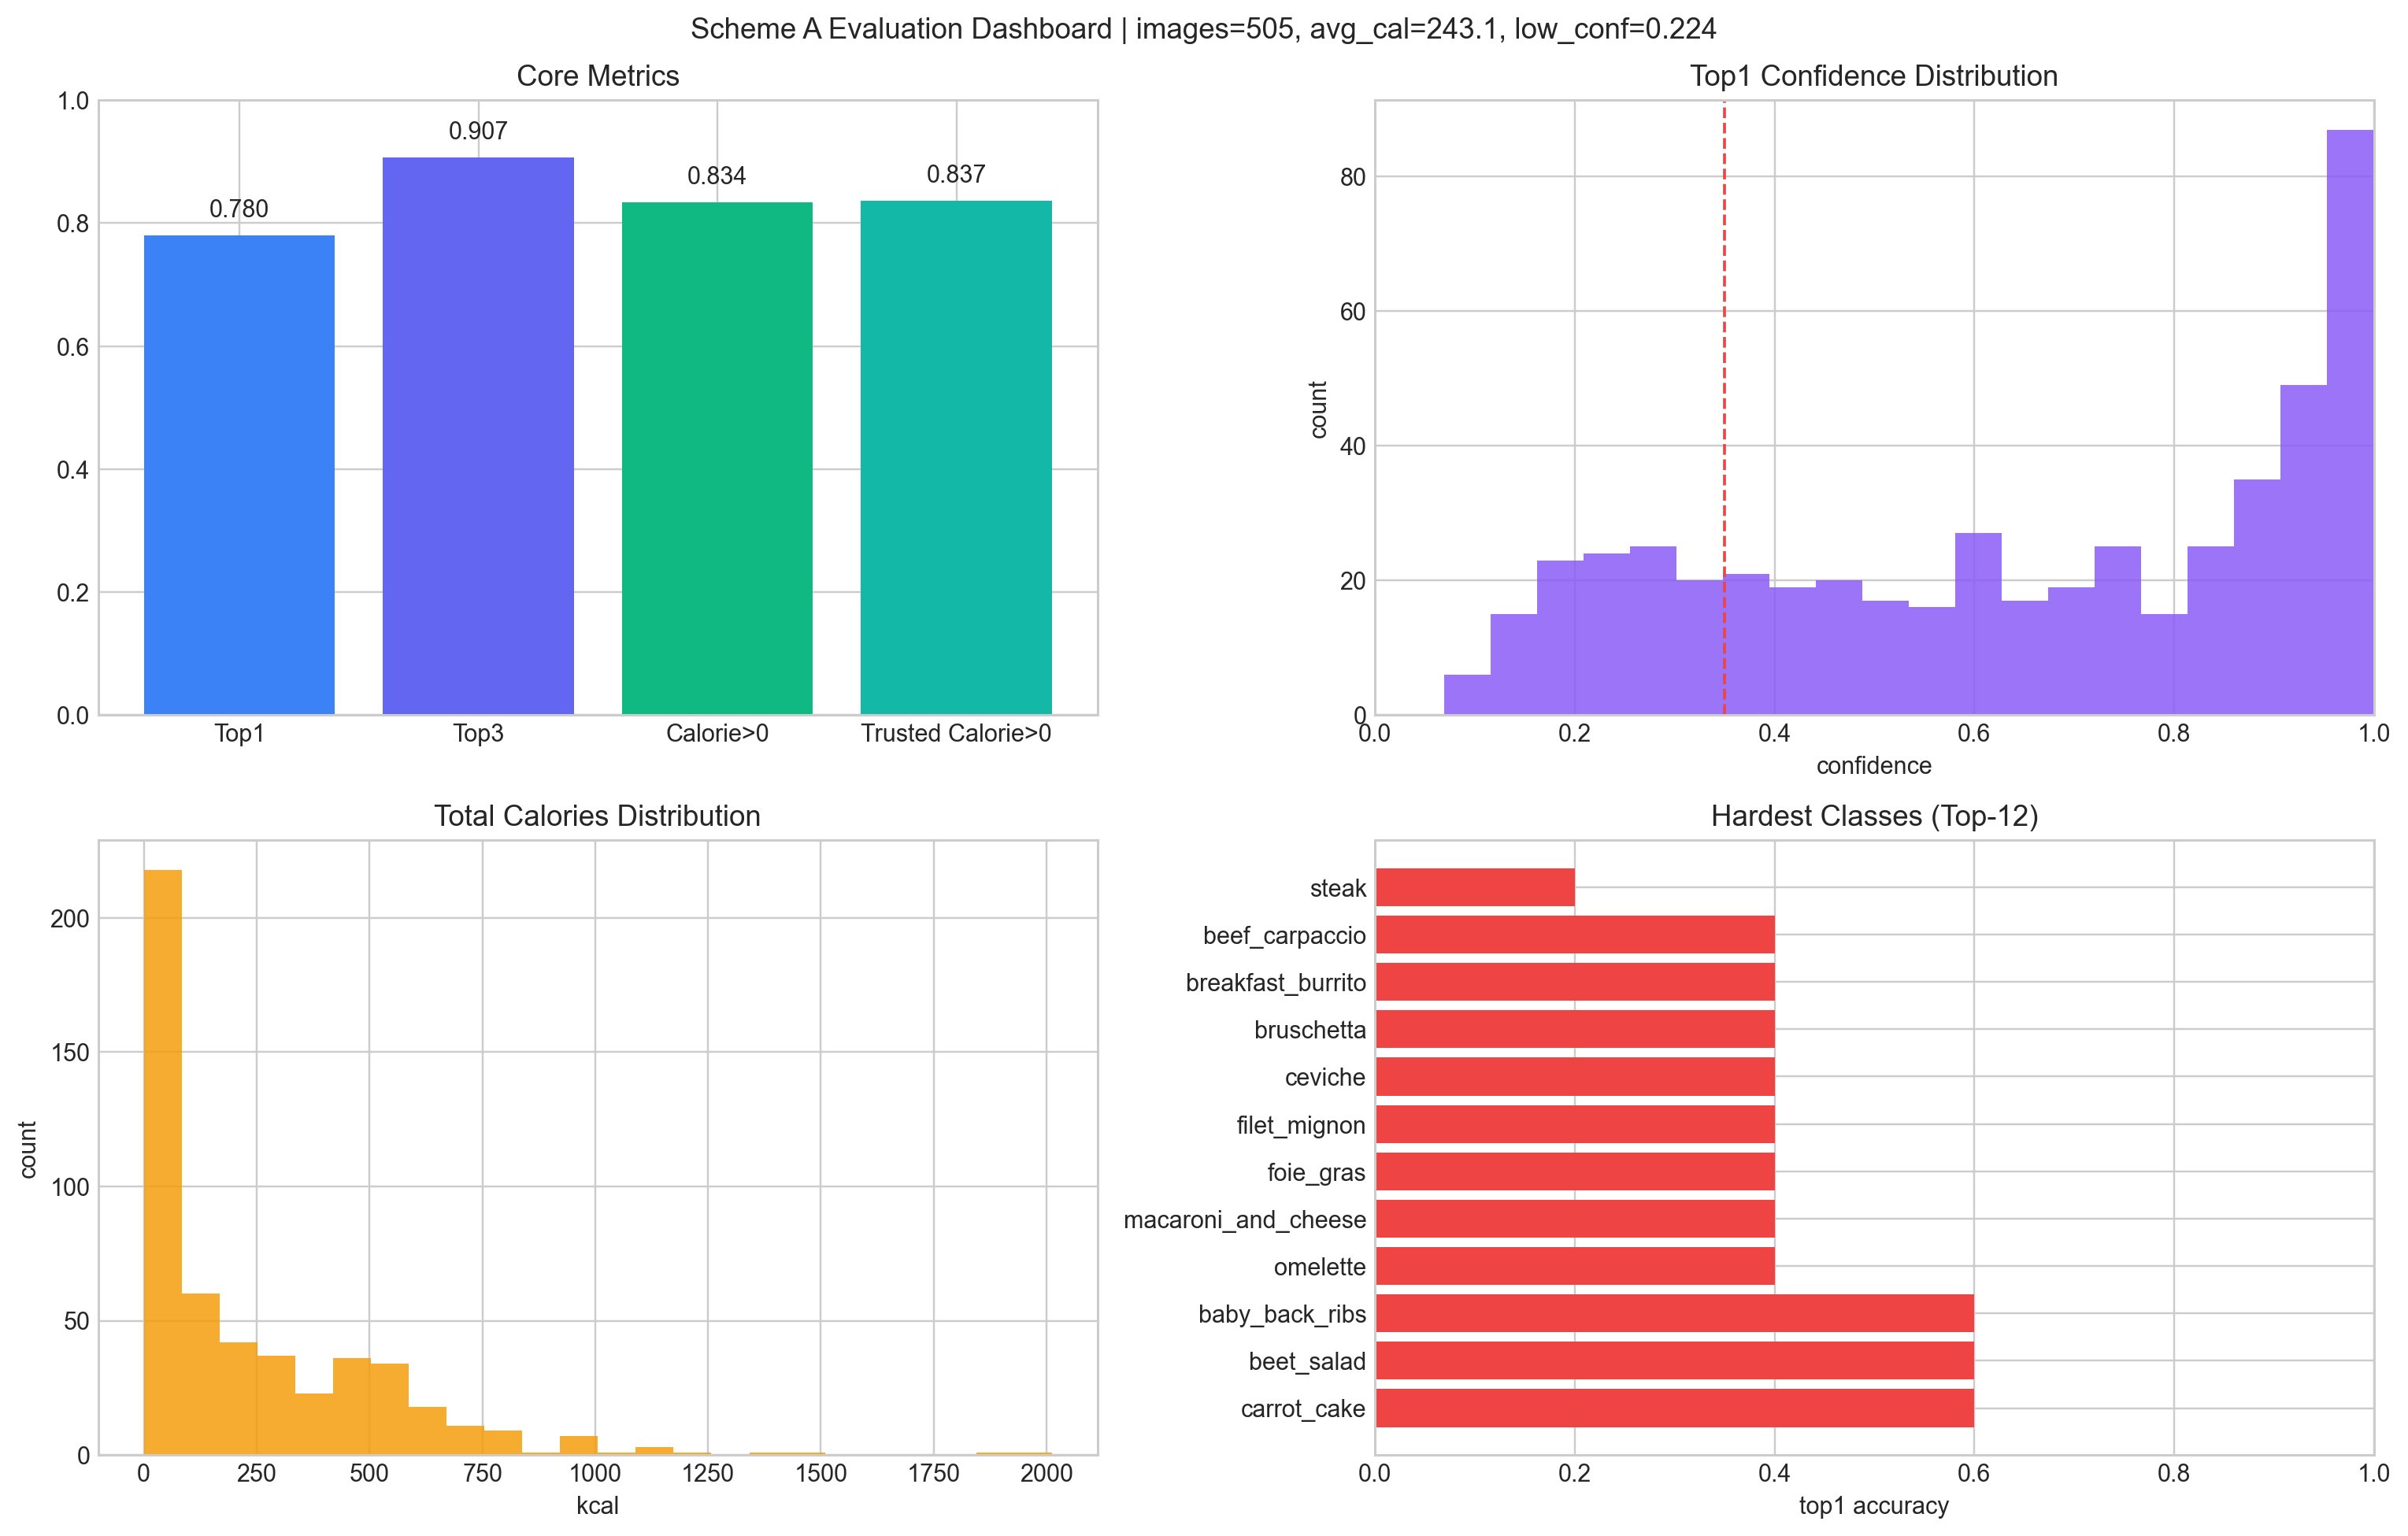

[preview] confidence_tradeoff: d:\CityU\Projects\CV_course_project\outputs\report_figures\report_confidence_tradeoff.png


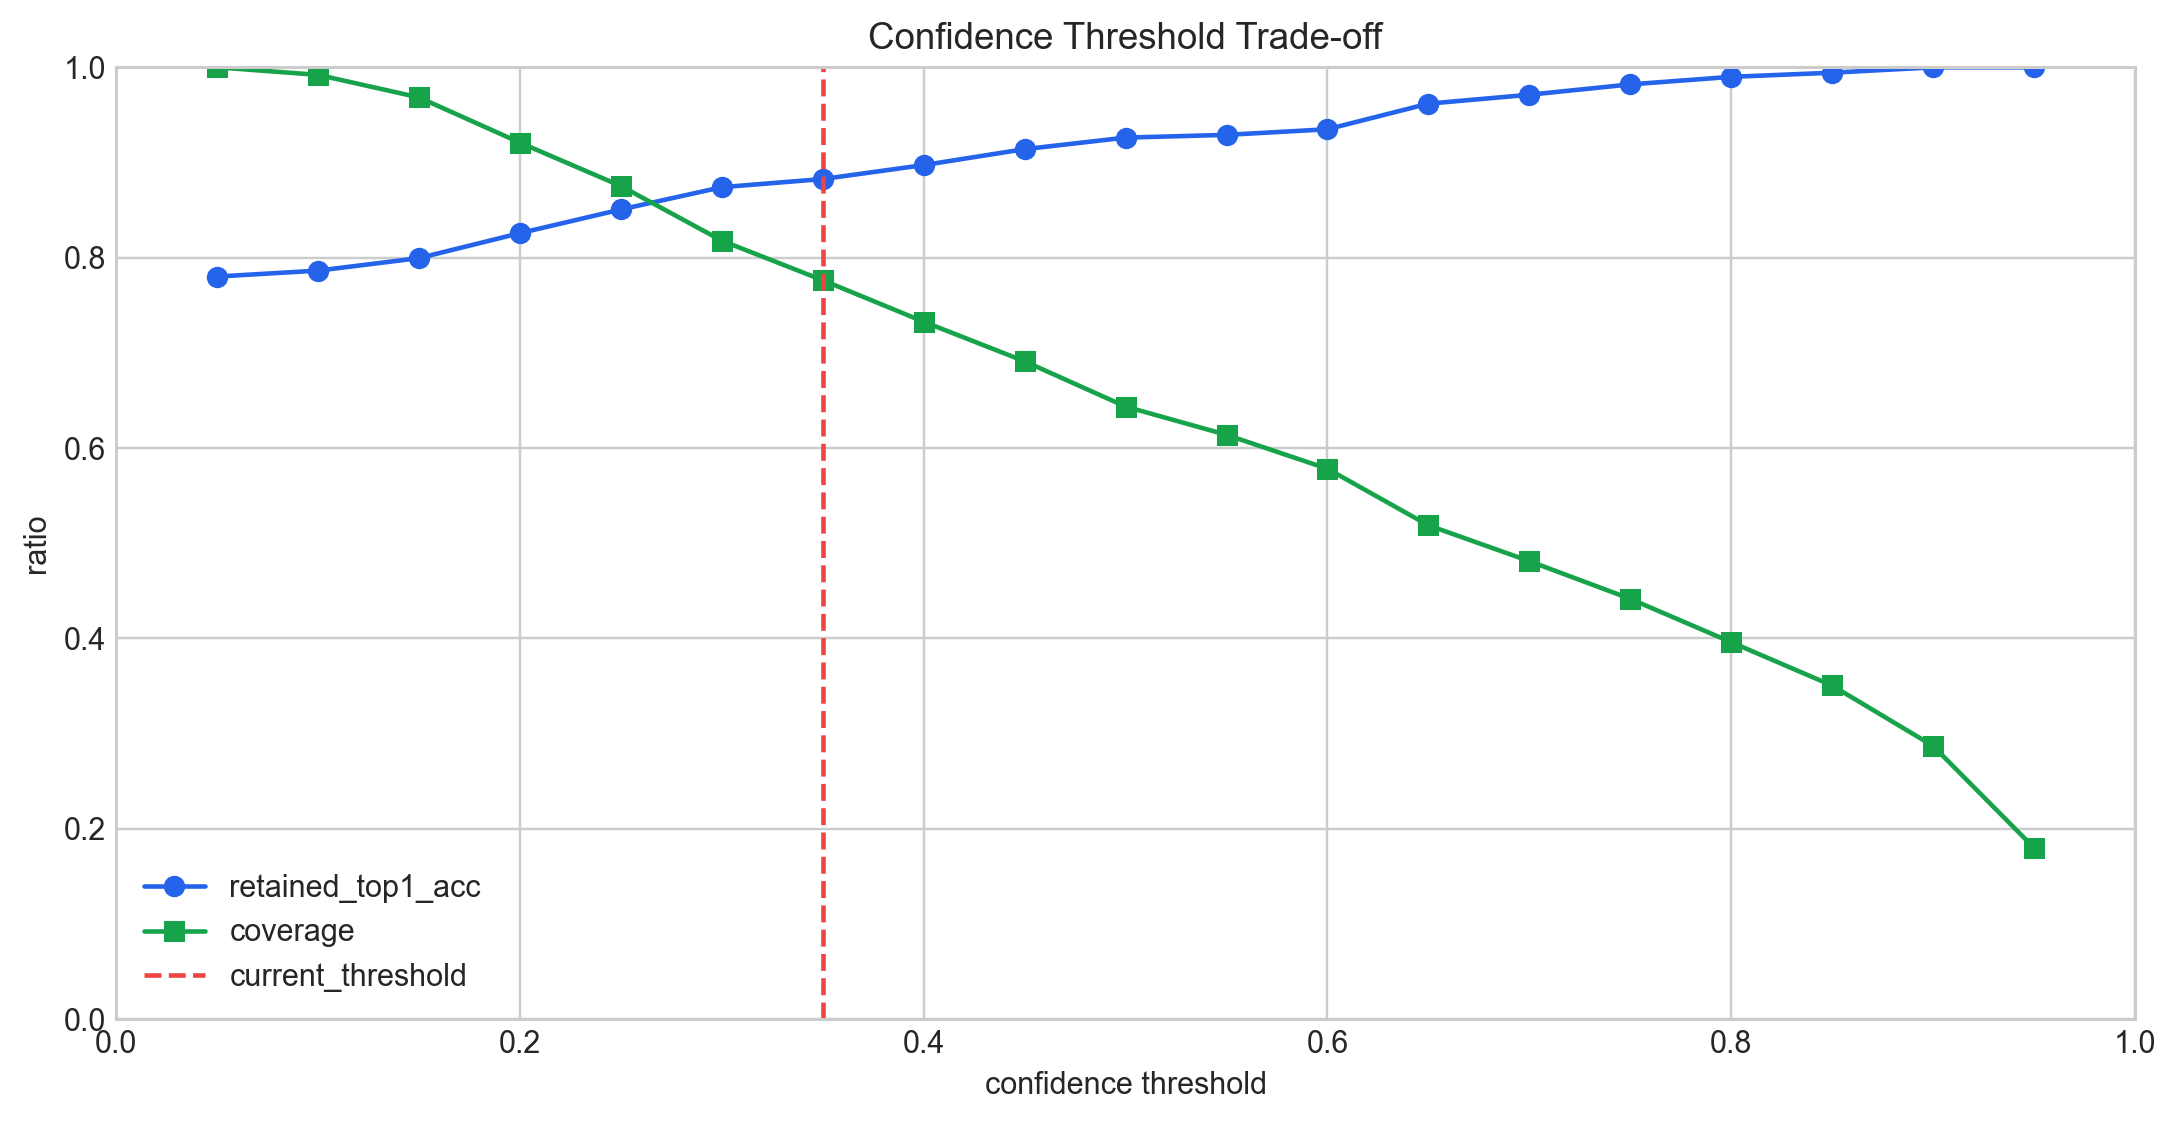

In [1]:
# 绘图：调用报告可视化模块（4页报告友好）
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from food_cv.visualization import ReportVizConfig, export_report_figures, quick_report_plan

scheme_csv = PROJECT_ROOT / "outputs" / "scheme_a_test_results.csv"
fig_dir = PROJECT_ROOT / "outputs" / "report_figures"

if not scheme_csv.exists():
    raise FileNotFoundError(f"未找到批测结果文件: {scheme_csv}")

cfg = ReportVizConfig(
    confidence_threshold=0.35,
    top_error_classes=12,
    top_class_table_size=20,
    dpi=220,
)

# 正文建议：2 张主图；类细节图仅答辩/附录备用。
saved = export_report_figures(
    scheme_csv_path=scheme_csv,
    output_dir=fig_dir,
    cfg=cfg,
    include_class_detail=False,
)

print("[main] report figures exported:")
print(json.dumps(saved, ensure_ascii=False, indent=2))
print("[main] recommended report plan:")
print(json.dumps(quick_report_plan(), ensure_ascii=False, indent=2))

# 可视化预览（Notebook 内展示）
try:
    from IPython.display import Image, display
    for key in ["dashboard", "confidence_tradeoff"]:
        p = Path(saved[key])
        if p.exists():
            print(f"[preview] {key}: {p}")
            display(Image(filename=str(p)))
except Exception as e:
    print(f"[main] 预览失败，可直接打开输出目录查看图片: {fig_dir} | err={e}")

In [13]:
try:
    from google.colab import drive
except Exception:
    print('[main] 非 Colab 环境：跳过 drive 挂载与仓库克隆单元')
else:
    import os
    from pathlib import Path
    drive.mount('/content/drive')
    GITHUB_TOKEN = os.getenv('GITHUB_TOKEN', '')
    REPO_OWNER = 'Blank4cc'
    REPO_NAME = 'VisualDietician'
    if not GITHUB_TOKEN:
        raise RuntimeError('请先在 Colab 环境变量中设置 GITHUB_TOKEN')
    PRIVATE_REPO_URL = f'https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git'
    DEST_PATH = f'/content/drive/MyDrive/{REPO_NAME}'
    if not os.path.exists(DEST_PATH):
        print('正在尝试克隆私有仓库...')
        get_ipython().system(f'git clone {PRIVATE_REPO_URL} {DEST_PATH}')
    else:
        print(f'目录已存在: {DEST_PATH}')
    if os.path.exists(DEST_PATH):
        os.chdir(DEST_PATH)
        print(f'成功进入目录: {os.getcwd()}')
        get_ipython().system('ls')
    else:
        print('克隆仍然失败，请检查 Token 权限或仓库路径是否正确。')
    Path(DEST_PATH)

ModuleNotFoundError: No module named 'google'

In [7]:
import os
from pathlib import Path

DEST_PATH = globals().get('DEST_PATH', str(Path.cwd()))
if os.path.exists(DEST_PATH):
    os.chdir(DEST_PATH)
    get_ipython().system('git pull')
    print("代码已尝试更新。")
else:
    print(f"未找到目录 {DEST_PATH}，已跳过 git pull。")

Already up to date.
代码已尝试更新。


In [8]:
import sys
from pathlib import Path

# 将当前路径（包含 src 目录的路径）加入 sys.path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

print("当前 Python 路径已更新，现在可以尝试运行之前的代码单元格了。")

当前 Python 路径已更新，现在可以尝试运行之前的代码单元格了。
